In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Advertising.csv")


In [5]:
print(df.shape)

(200, 5)


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [7]:
print(df.describe())

       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


In [8]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [9]:
X = df.drop(columns=['Sales'])
y = df['Sales']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [13]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [14]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge


In [15]:
lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)


In [19]:
lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

Ridge(alpha=0.1)

In [20]:
y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [22]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_lasso, "Lasso")
evaluate(y_test, y_pred_ridge, "Ridge")


Linear Regression
R2 Score: 0.899438024100912
MAE: 1.4607567168117606
MSE: 3.1740973539761046

Lasso
R2 Score: 0.8995513046486308
MAE: 1.4597951733194978
MSE: 3.1705218127881327

Ridge
R2 Score: 0.899438032178932
MAE: 1.460757606304266
MSE: 3.1740970990047614


In [23]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

print(coef_df)

     Feature    Linear     Lasso     Ridge
0         TV  0.044730  0.044720  0.044730
1      Radio  0.189195  0.188811  0.189194
2  Newspaper  0.002761  0.002627  0.002761


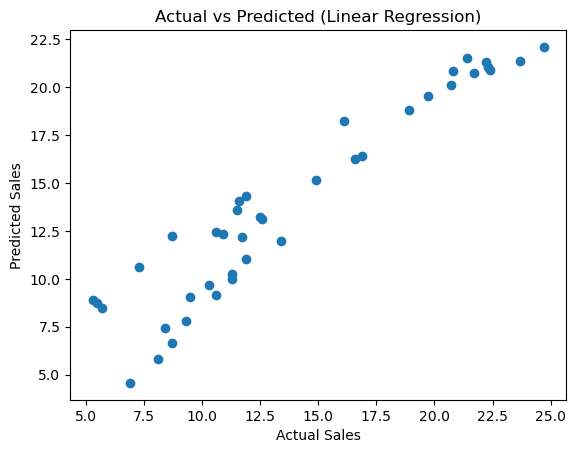

In [24]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


In [26]:


from sklearn.model_selection import cross_val_score



In [27]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print("\nCross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())


Cross Validation R2 Scores: [0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]
Average CV Score: 0.8871063495438435


In [1]:
print("\n========== PROJECT INSIGHTS ==========\n")

print("1. TV advertising has the strongest overall impact on Sales.")
print("2. Radio advertising also contributes significantly to Sales.")
print("3. Newspaper advertising has very low impact compared to TV and Radio.")
print("4. Lasso Regression helps identify weak features by shrinking coefficients.")
print("5. Ridge Regression reduces coefficient magnitude and improves stability.")
print("6. VIF analysis helps detect multicollinearity among features.")
print("7. The model achieved a strong R2 score, meaning it explains most Sales variation.")
print("8. Scatter plot showed predictions are close to actual values.")
print("9. Cross-validation confirmed that model performance is stable.")
print("10. Overall, advertising budget is strongly related to Sales prediction.")


========== PROJECT INSIGHTS ==========

1. TV advertising has the strongest overall impact on Sales.
2. Radio advertising also contributes significantly to Sales.
3. Newspaper advertising has very low impact compared to TV and Radio.
4. Lasso Regression helps identify weak features by shrinking coefficients.
5. Ridge Regression reduces coefficient magnitude and improves stability.
6. VIF analysis helps detect multicollinearity among features.
7. The model achieved a strong R2 score, meaning it explains most Sales variation.
8. Scatter plot showed predictions are close to actual values.
9. Cross-validation confirmed that model performance is stable.
10. Overall, advertising budget is strongly related to Sales prediction.
